# 1. IMPORT **LIBRARIES**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. LOAD **DATA**

In [16]:
df = pd.read_csv('../data/data_ecommerce_customer_churn.csv')

In [17]:
print("Initial Shape:", df.shape)
print(df.head())

Initial Shape: (3941, 11)
   Tenure  WarehouseToHome  NumberOfDeviceRegistered    PreferedOrderCat  \
0    15.0             29.0                         4  Laptop & Accessory   
1     7.0             25.0                         4              Mobile   
2    27.0             13.0                         3  Laptop & Accessory   
3    20.0             25.0                         4             Fashion   
4    30.0             15.0                         4              Others   

   SatisfactionScore MaritalStatus  NumberOfAddress  Complain  \
0                  3        Single                2         0   
1                  1       Married                2         0   
2                  1       Married                5         0   
3                  3      Divorced                7         0   
4                  4        Single                8         0   

   DaySinceLastOrder  CashbackAmount  Churn  
0                7.0          143.32      0  
1                7.0          129.

# 3. HANDLE MISSING **VALUES**

In [18]:
# Fill numeric with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_10754/1713109052.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_10754/1713109052.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

# 4. FIX **OUTLIERS (IQR METHOD)**

In [19]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# 5. FEATURE **ENGINEERING**

In [20]:
# EngagementScore (example logic)
df['EngagementScore'] = (
    df['NumberOfDeviceRegistered'] * 0.4 +
    df['CashbackAmount'] * 0.3 +
    df['Tenure'] * 0.3
)

# RecentOrder (1 if last order within 30 days)
df['RecentOrder'] = np.where(df['DaySinceLastOrder'] <= 30, 1, 0)

# UnhappyCustomer (complaints > 0)
df['UnhappyCustomer'] = np.where(df['Complain'] > 0, 1, 0)

# LoyaltyTier
df['LoyaltyTier'] = pd.cut(
    df['Tenure'],
    bins=[0, 6, 12, 24, 60],
    labels=['New', 'Regular', 'Loyal', 'VIP']
)

# CashbackPerOrder
df['CashbackPerOrder'] = df['CashbackAmount'] / (df['NumberOfDeviceRegistered'] + 1)

# HighCouponUser - Removed due to KeyError: 'CouponUsed'
# df['HighCouponUser'] = np.where(df['CouponUsed'] > df['CouponUsed'].median(), 1, 0)

# 6. EDA **VISUALIZATION**

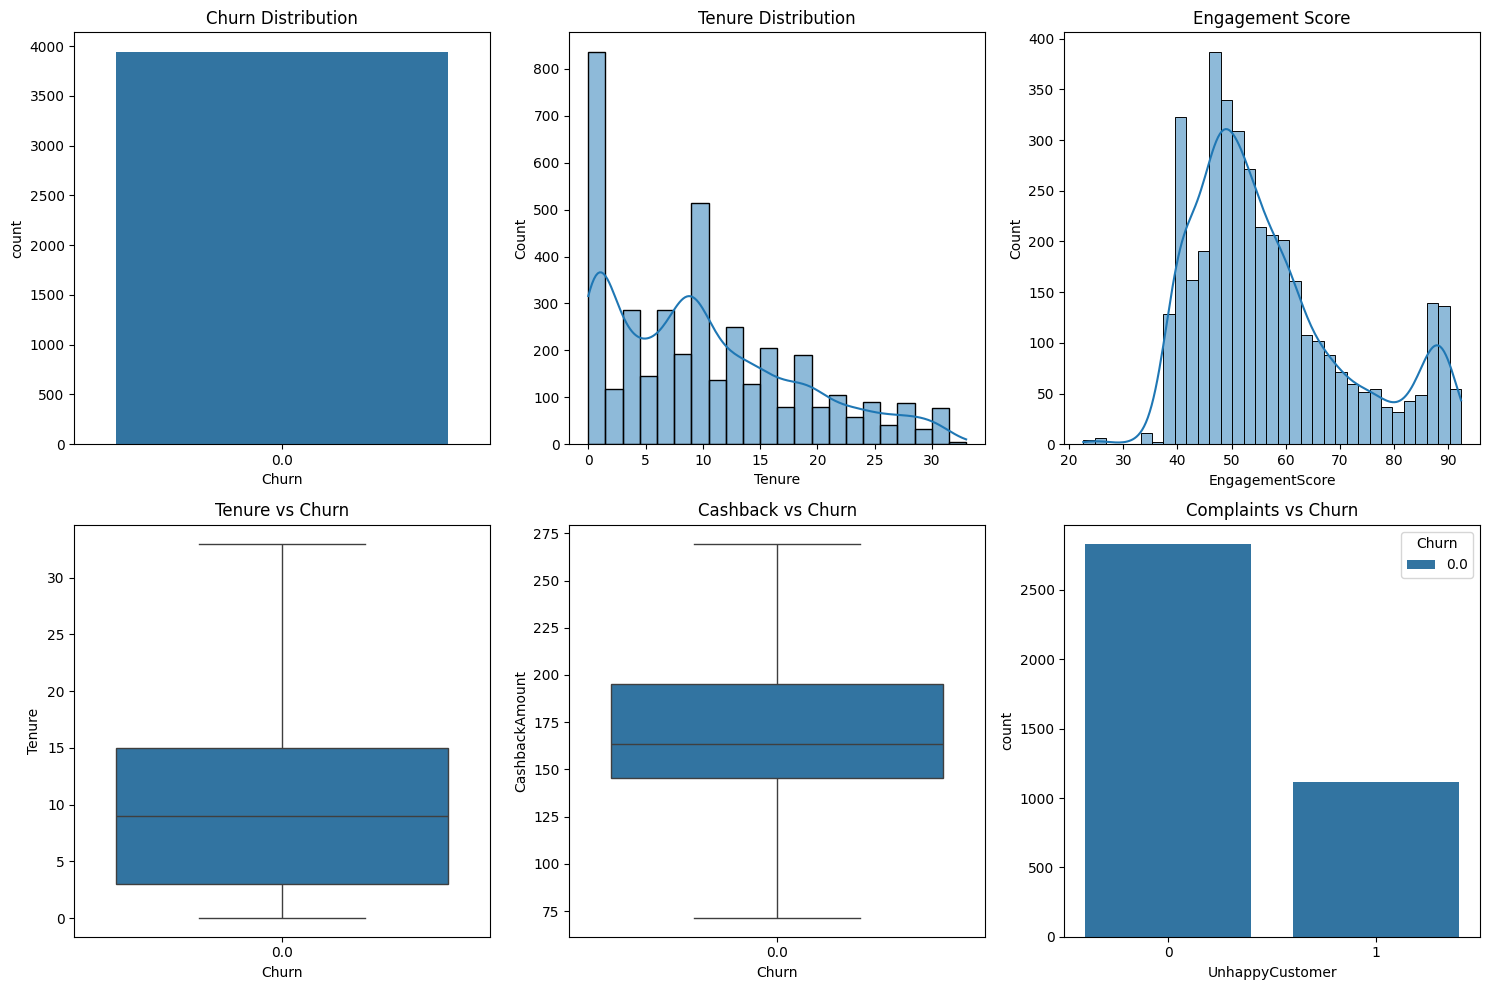

In [21]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")

plt.subplot(2,3,2)
sns.histplot(df['Tenure'], kde=True)
plt.title("Tenure Distribution")

plt.subplot(2,3,3)
sns.histplot(df['EngagementScore'], kde=True)
plt.title("Engagement Score")

plt.subplot(2,3,4)
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title("Tenure vs Churn")

plt.subplot(2,3,5)
sns.boxplot(x='Churn', y='CashbackAmount', data=df)
plt.title("Cashback vs Churn")

plt.subplot(2,3,6)
sns.countplot(x='UnhappyCustomer', hue='Churn', data=df)
plt.title("Complaints vs Churn")

plt.tight_layout()
plt.savefig('../outputs/churn_eda.png')
plt.show()

# 7. CORRELATION **HEATMAP**

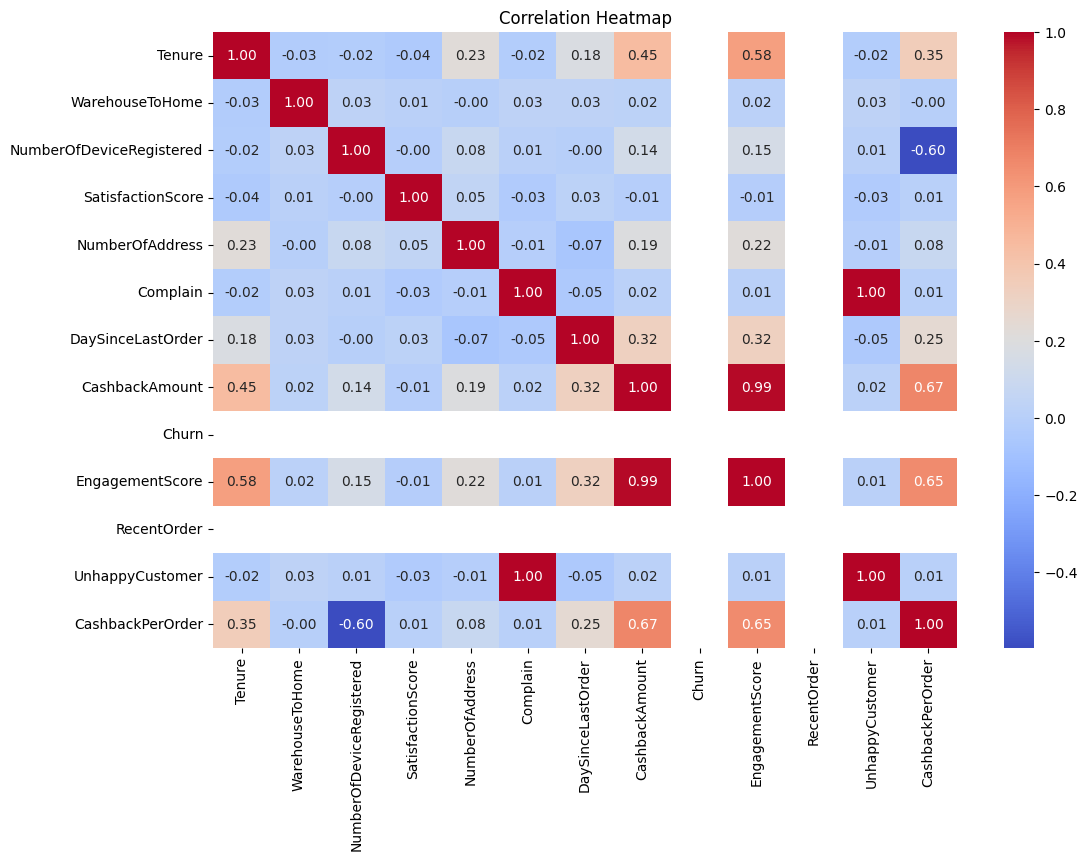

In [22]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")

plt.savefig('/content/churn_correlation.png')
plt.show()

# 8. SAVE CLEAN **DATA**

In [23]:
df.to_csv('/content/cleaned_churn_data.csv', index=False)

print("Files Saved:")
print("cleaned_churn_data.csv")
print("churn_eda.png")
print("churn_correlation.png")

Files Saved:
cleaned_churn_data.csv
churn_eda.png
churn_correlation.png
